In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np

In [3]:
project_path = 'drive/MyDrive/handwriting_recognition'

In [4]:
sys.path.append(project_path)

In [5]:
sys.path

['/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython',
 'drive/MyDrive/handwriting_recognition']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 114.6 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=9682a4591f1ae2fad6b4818bac28d06f088455b5539bf9b46e9004dcd5f6d1ca
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
!python -c "import zarr; print(f'Zarr version: {zarr.__version__}')"

Zarr version: 2.18.7


In [8]:
from src.io.exceptions import SerializationError, UnsupportedFormatError, DeserializationError

In [9]:
from src.io.logging import LoggerFactory

In [10]:
from src import ImageTransformer, ImageAnalyzer, LineSegmentProcessor, AuthorProcessor, save, FileSystem, AuthorDatasetBuilder

In [11]:
fileSystem = FileSystem()

In [12]:
data_path = fileSystem.to_path("drive/MyDrive/handwriting data")

author_images_dir = fileSystem.to_path(f"{data_path}/1_ImagesRotated")
author_mat_dir = fileSystem.to_path(f"{data_path}/5_DataDarkLines")

In [13]:
def natural_key(name: str) -> list:
  return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', name)]

In [14]:
# List of all the files names
authors_images: list = glob.glob(f"{author_images_dir}/*.jpg")

# get only the file name without the extension
authors_names_filenames: list = [os.path.splitext(os.path.basename(filename))[0]
                for filename in authors_images]

authors_names: list[str] = sorted(authors_names_filenames, key=natural_key)

In [15]:
transformer = ImageTransformer()
analyzer = ImageAnalyzer()
line_processor = LineSegmentProcessor()

In [16]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [17]:
logger = LoggerFactory.get_notebook_logger("dataset_generation", log_dir=f"./logs_{current_time}")

In [13]:
logger = LoggerFactory.get_notebook_logger("dataset_generation", log_dir=f"./logs_20260122-142244")

In [14]:
metadata = {
    'patch_size': (180, 160),
    'stride_x': 30,
    'threshold': 0.95,
    'val_size': 0.15,
    'seed': 42,
}

In [19]:
from src.processors import AuthorDataLoader

In [20]:
data_loader = AuthorDataLoader(
    images_dir=author_images_dir,
    mat_dir=author_mat_dir,
    transformer=transformer
)

In [21]:
def create_author_processor(label_id: int, author: str) -> AuthorProcessor:

  return AuthorProcessor(
    label_id=label_id,
    author=author,
    data_loader=data_loader,
    analyzer=analyzer,
    line_processor=line_processor,
    **metadata,
  )

In [22]:
builder = AuthorDatasetBuilder(
    authors_names=authors_names,
    author_processor_factory=create_author_processor,
    metadata=metadata,
)

In [15]:
drive_output_path = f"{project_path}/data/datasets"

In [24]:
failed_authors = []

In [25]:
pbar = tqdm(authors_names, desc="Processing authors")
for label_id, author in enumerate(pbar):
  pbar.set_postfix(current_author=author)
  try:
    builder.process_author(label_id, author)
  except ValueError as e:
    logger.warning(f"Skipping author {author}: {e}")
    failed_authors.append((author, str(e)))
  except Exception as e:
    logger.error(f"Unexpected error processing author {author}: {e}", exc_info=True)
    failed_authors.append((author, f"CRITICAL: {e}"))

Processing authors: 100%|██████████| 407/407 [08:33<00:00,  1.26s/it, current_author=lines7_Page_62]


In [26]:
if failed_authors:
    logger.warning(f"Failed to process {len(failed_authors)} authors:")
    for author, reason in failed_authors:
        logger.warning(f"  - {author}: {reason}")

In [27]:
dataset = builder.build_dataset(current_time)

In [ ]:
try:
    save(directory=drive_output_path, data=dataset, filename=f"complete_dataset_{current_time}.zarr")
except (SerializationError, OSError) as e:
    logger.error(f"CRITICAL: Failed to save dataset: {e}")
    raise

In [36]:
dataset_path = f"./complete_dataset_{current_time}.zarr"

In [37]:
def get_size_mb(dataset_path: str) -> float:
  from pathlib import Path
  path = Path(dataset_path)

  if not path.is_dir():
    return path.stat().st_size / 1024 / 1024

  total_size = 0
  for file_path in path.rglob("*"):
    if file_path.is_file():
      total_size += file_path.stat().st_size

  return total_size / 1024 / 1024

In [38]:
dataset_file = fileSystem.to_path(dataset_path)
total_patches = len(dataset['labels'])
file_size_mb = get_size_mb(dataset_path=dataset_file)

In [39]:
logger.info(f"\n✅ Dataset saved successfully!")
logger.info(f"   File: {dataset_file}")
logger.info(f"   Size: {file_size_mb:.2f} MB")
logger.info(f"   Authors: {dataset['num_authors']}")
logger.info(f"   Total patches: {len(dataset['labels'])}")
logger.info(f"   Train: {len(dataset['partition']['train'])}")
logger.info(f"   Validation: {len(dataset['partition']['validation'])}")
logger.info(f"   Test: {len(dataset['partition']['test'])}")

INFO - 
✅ Dataset saved successfully!
INFO -    File: complete_dataset_20260122-142244.zarr
INFO -    Size: 473.06 MB
INFO -    Authors: 407
INFO -    Total patches: 1526159
INFO -    Train: 1268876
INFO -    Validation: 206216
INFO -    Test: 51067


In [40]:
logger.info("📊 Análisis del Test Set:")
logger.info(f"\nTest patches por autor:")
test_per_author = len(dataset['partition']['test']) / dataset['num_authors']
logger.info(f"  Promedio: {test_per_author:.0f} patches/autor")

# Verificar distribución
test_counts = []
for author_id in range(len(authors_names)):
    if author_id in dataset['author_indices']['test']:
        start, end = dataset['author_indices']['test'][author_id]
        test_counts.append(end - start)

if test_counts:
    import numpy as np
    logger.info(f"  Min: {np.min(test_counts)} patches")
    logger.info(f"  Max: {np.max(test_counts)} patches")
    logger.info(f"  Std: {np.std(test_counts):.1f} patches")

logger.info(f"\n¿Es suficiente? {test_per_author >= 100 and '✅ Sí' or '⚠️ Podría ser poco'}")

INFO - 📊 Análisis del Test Set:
INFO - 
Test patches por autor:
INFO -   Promedio: 125 patches/autor
INFO -   Min: 79 patches
INFO -   Max: 146 patches
INFO -   Std: 9.3 patches
INFO - 
¿Es suficiente? ✅ Sí


In [41]:
logger.info("\n📊 Análisis de Proporción Train/Val:")
resto = len(dataset['partition']['train']) + len(dataset['partition']['validation'])
val_ratio = len(dataset['partition']['validation']) / resto
train_ratio = len(dataset['partition']['train']) / resto

logger.info(f"  Del resto (Train + Val = {resto:,} patches):")
logger.info(f"    Train: {train_ratio*100:.2f}%")
logger.info(f"    Val: {val_ratio*100:.2f}%")
logger.info(f"  Target Val: 15.00%")
logger.info(f"  Error: {(val_ratio - 0.15)*100:+.2f}%")

if abs(val_ratio - 0.15) < 0.01:
    logger.info(f"  ✅ Excelente precisión!")
elif abs(val_ratio - 0.15) < 0.02:
    logger.info(f"  ✅ Buena precisión")
else:
    logger.warning(f"  ⚠️ Revisar algoritmo de partición")

INFO - 
📊 Análisis de Proporción Train/Val:
INFO -   Del resto (Train + Val = 1,475,092 patches):
INFO -     Train: 86.02%
INFO -     Val: 13.98%
INFO -   Target Val: 15.00%
INFO -   Error: -1.02%
INFO -   ✅ Buena precisión


In [42]:
del dataset
gc.collect()

261

In [16]:
from src import SelectiveDataLoader

In [17]:
from src.io import load

In [18]:
dataset_path = f"{project_path}/data/datasets/complete_dataset_20260122-142244.tar.gz"

In [19]:
!tar -xzf {dataset_path} -C ./

In [20]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

15:31:39 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
15:31:39 - ZarrSerializer - INFO - ======================================================================
15:31:39 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
15:31:39 - ZarrSerializer - INFO - ======================================================================
15:31:39 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
15:31:39 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
15:31:39 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
15:31:39 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
15:31:39 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
15:31:39 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
15:31:39 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
15:31:39 - ZarrSerializer - INFO - ======================

In [21]:
import matplotlib.pyplot as plt

In [22]:
def display_author_patches(images: tuple[np.ndarray, np.ndarray]) -> None:
  X, y = images
  logger.info(f"  - X shape: {X.shape}")
  logger.info(f"  - y shape: {y.shape}")
  logger.info(f"  - Unique authors: {len(np.unique(y))}")
  # Show 5 random patches from training set
  fig, axes = plt.subplots(1, 5, figsize=(15, 3))
  indices = np.random.choice(len(X), 5, replace=False)

  for i, idx in enumerate(indices):
      axes[i].imshow(X[idx], cmap='gray')
      axes[i].set_title(f"Author {y[idx]}")
      axes[i].axis('off')

  plt.tight_layout()
  plt.show()

In [23]:
def safe_load_authors(loader: SelectiveDataLoader, authors_id: list[int] | range) -> None:
  try:
    logger.info(f"Loading {len(list(authors_id))} authors")
    subset = loader.load_dataset_by_authors(authors_id, show_progress_bar=True)
    logger.info(f"✅ Loaded successfully:")
    display_author_patches(subset['train'])
    display_author_patches(subset['validation'])
    display_author_patches(subset['test'])

    del subset
    gc.collect()
  except ValueError as e:
    logger.error(f"❌ Invalid parameters: {e}")

  except MemoryError as e:
    logger.error(f"❌ Not enough memory to load data")
    logger.error(f"Try loading fewer authors at a time")

  except Exception as e:
    logger.error(f"❌ Unexpected error: {e}", exc_info=True)

INFO - Loading 50 authors
15:31:48 - ZarrSerializer - INFO - ======================================================================
15:31:48 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
15:31:48 - ZarrSerializer - INFO - ======================================================================
15:31:48 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
15:31:48 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
15:31:48 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
15:31:48 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
15:31:48 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
15:31:48 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
15:31:48 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
15:31:48 - ZarrSerializer - INFO - ======================================================================
15:31

Building subset dataset: 100%|██████████| 150/150 [00:18<00:00,  7.92it/s]

INFO - ✅ Loaded successfully:


INFO -   - X shape: (153701, 180, 160)
INFO -   - y shape: (153701,)
INFO -   - Unique authors: 50


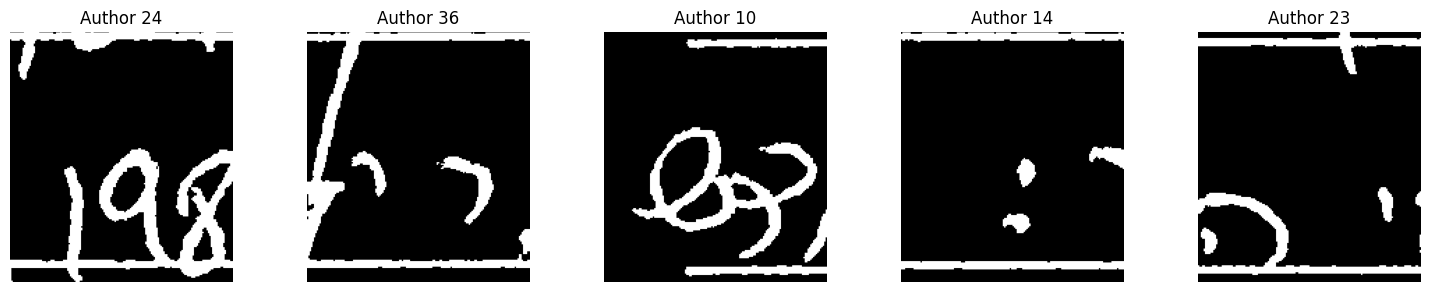

INFO -   - X shape: (24954, 180, 160)
INFO -   - y shape: (24954,)
INFO -   - Unique authors: 50


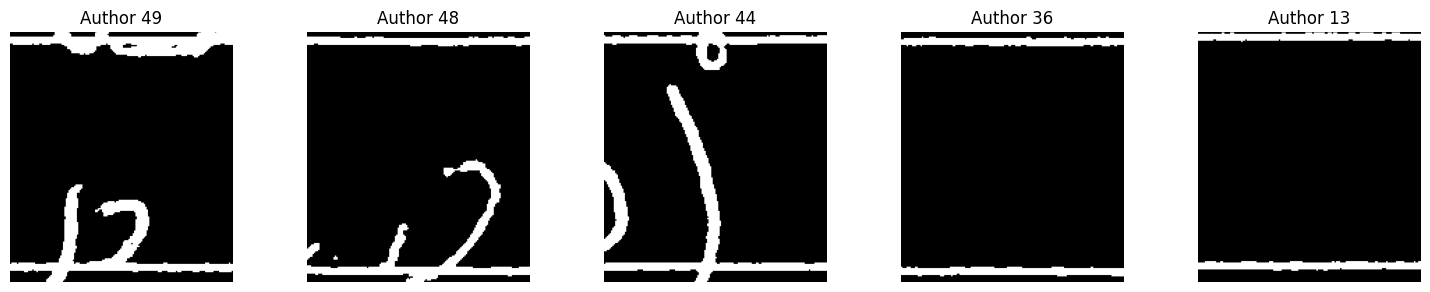

INFO -   - X shape: (6201, 180, 160)
INFO -   - y shape: (6201,)
INFO -   - Unique authors: 50


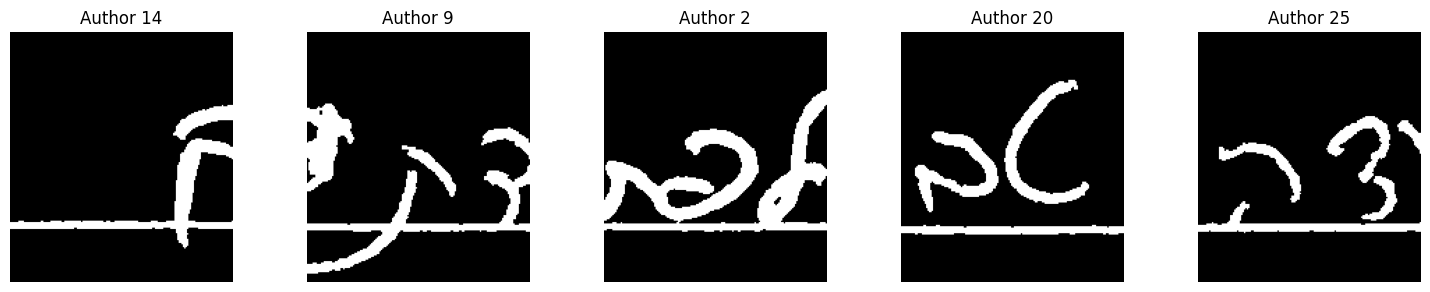

In [24]:
safe_load_authors(loader, range(50))

INFO - Loading 50 authors
15:32:27 - ZarrSerializer - INFO - ======================================================================
15:32:27 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
15:32:27 - ZarrSerializer - INFO - ======================================================================
15:32:27 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
15:32:27 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
15:32:27 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
15:32:27 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
15:32:27 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
15:32:27 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
15:32:27 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
15:32:27 - ZarrSerializer - INFO - ======================================================================
15:32

Building subset dataset: 100%|██████████| 150/150 [00:18<00:00,  7.93it/s]

INFO - ✅ Loaded successfully:


INFO -   - X shape: (156707, 180, 160)
INFO -   - y shape: (156707,)
INFO -   - Unique authors: 50


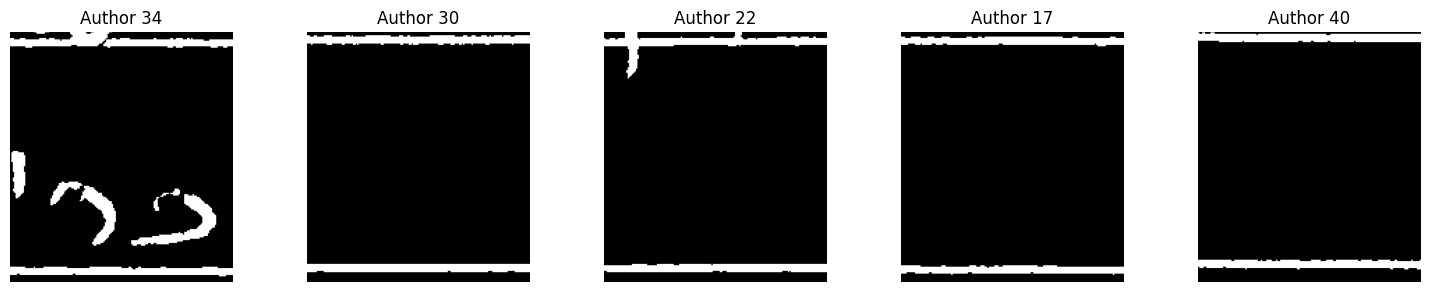

INFO -   - X shape: (25439, 180, 160)
INFO -   - y shape: (25439,)
INFO -   - Unique authors: 50


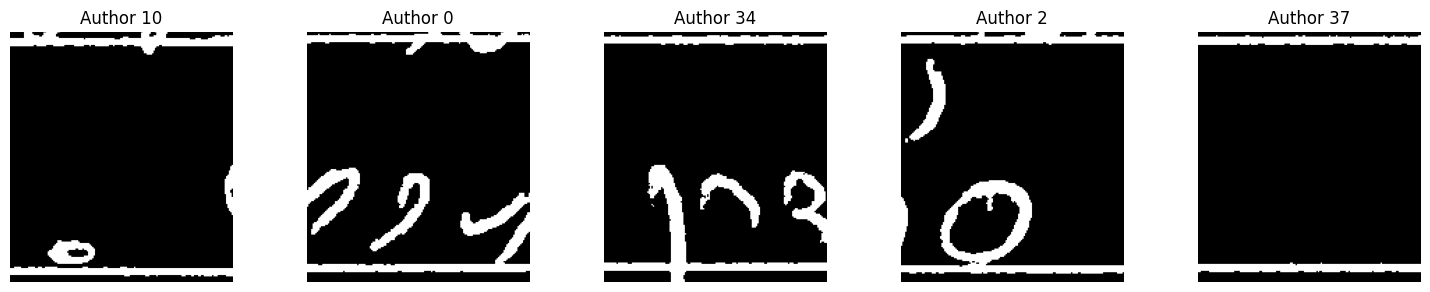

INFO -   - X shape: (6318, 180, 160)
INFO -   - y shape: (6318,)
INFO -   - Unique authors: 50


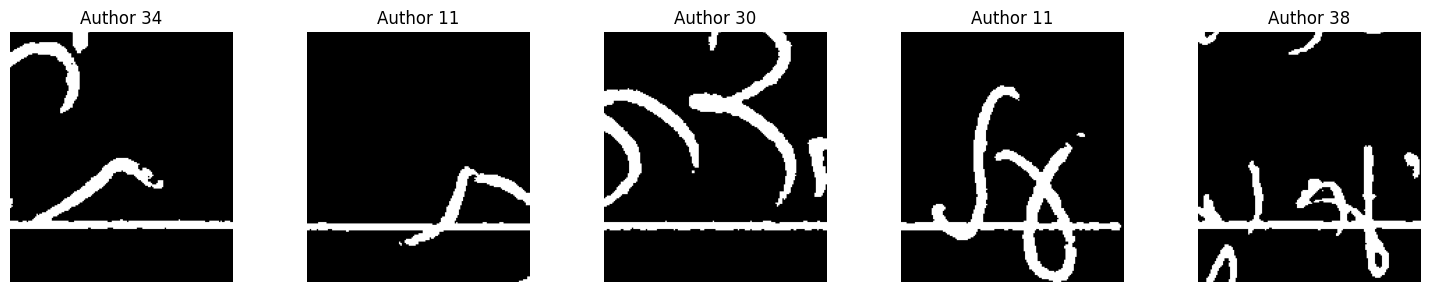

In [25]:
safe_load_authors(loader, range(50, 100))

INFO - Loading 100 authors
15:32:53 - ZarrSerializer - INFO - ======================================================================
15:32:53 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
15:32:53 - ZarrSerializer - INFO - ======================================================================
15:32:53 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
15:32:53 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
15:32:53 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
15:32:53 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
15:32:53 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
15:32:53 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
15:32:53 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
15:32:53 - ZarrSerializer - INFO - ======================================================================
15:3

Building subset dataset: 100%|██████████| 300/300 [00:39<00:00,  7.64it/s]

INFO - ✅ Loaded successfully:
INFO -   - X shape: (311922, 180, 160)
INFO -   - y shape: (311922,)
INFO -   - Unique authors: 100


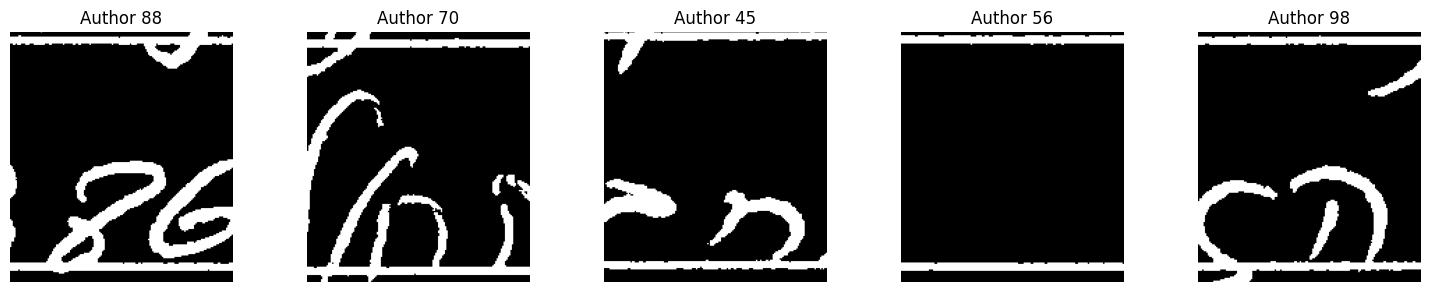

INFO -   - X shape: (50789, 180, 160)
INFO -   - y shape: (50789,)
INFO -   - Unique authors: 100


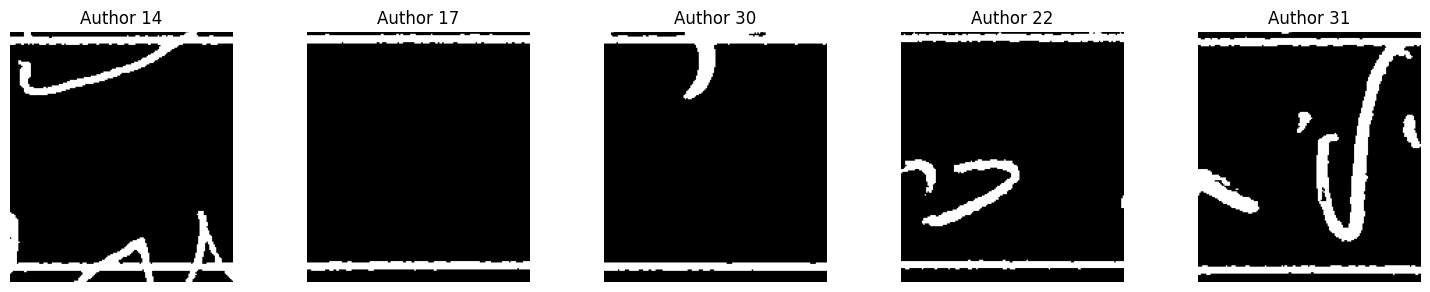

INFO -   - X shape: (12597, 180, 160)
INFO -   - y shape: (12597,)
INFO -   - Unique authors: 100


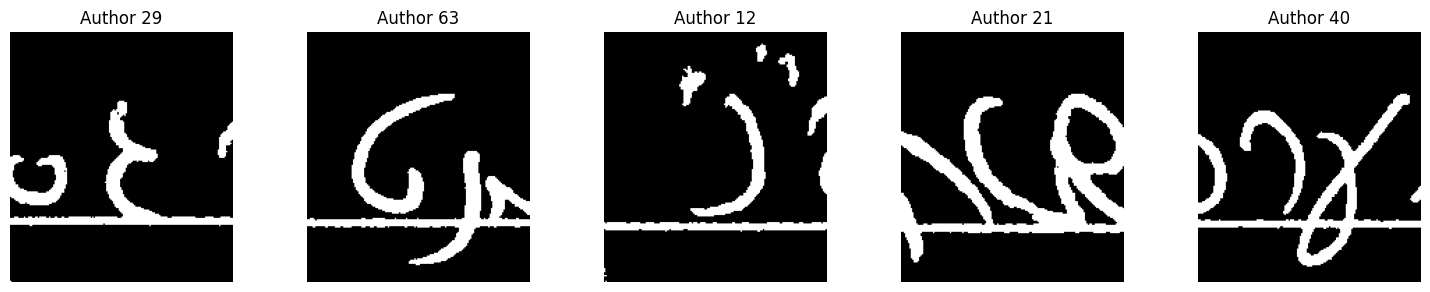

In [26]:
safe_load_authors(loader, range(100, 200))

INFO - Loading 100 authors
15:33:34 - ZarrSerializer - INFO - ======================================================================
15:33:34 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
15:33:34 - ZarrSerializer - INFO - ======================================================================
15:33:34 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
15:33:34 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
15:33:34 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
15:33:34 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
15:33:34 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
15:33:34 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
15:33:34 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
15:33:34 - ZarrSerializer - INFO - ======================================================================
15:3

Building subset dataset: 100%|██████████| 300/300 [00:40<00:00,  7.49it/s]

INFO - ✅ Loaded successfully:
INFO -   - X shape: (312454, 180, 160)
INFO -   - y shape: (312454,)
INFO -   - Unique authors: 100


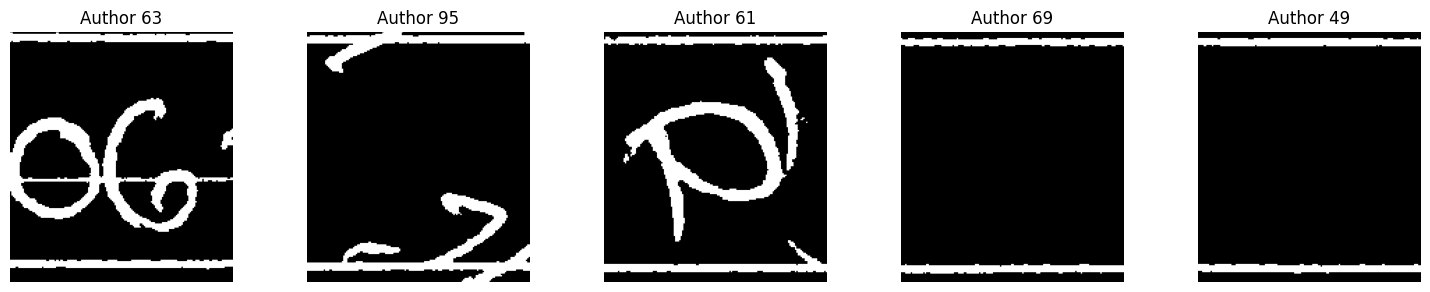

INFO -   - X shape: (50693, 180, 160)
INFO -   - y shape: (50693,)
INFO -   - Unique authors: 100


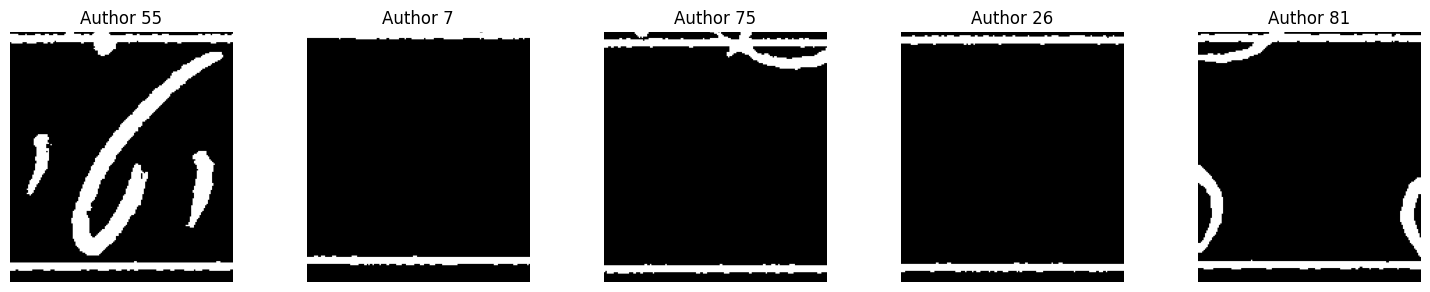

INFO -   - X shape: (12583, 180, 160)
INFO -   - y shape: (12583,)
INFO -   - Unique authors: 100


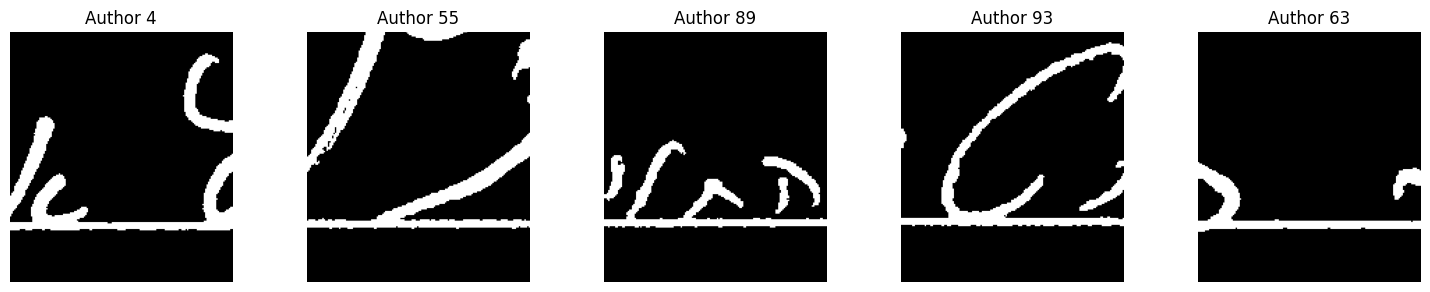

In [27]:
safe_load_authors(loader, range(200, 300))

INFO - Loading 107 authors
15:34:15 - ZarrSerializer - INFO - ======================================================================
15:34:15 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
15:34:15 - ZarrSerializer - INFO - ======================================================================
15:34:15 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
15:34:15 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
15:34:15 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
15:34:15 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
15:34:15 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
15:34:15 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
15:34:15 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
15:34:15 - ZarrSerializer - INFO - ======================================================================
15:3

Building subset dataset: 100%|██████████| 321/321 [00:42<00:00,  7.60it/s]


INFO - ✅ Loaded successfully:
INFO -   - X shape: (334092, 180, 160)
INFO -   - y shape: (334092,)
INFO -   - Unique authors: 107


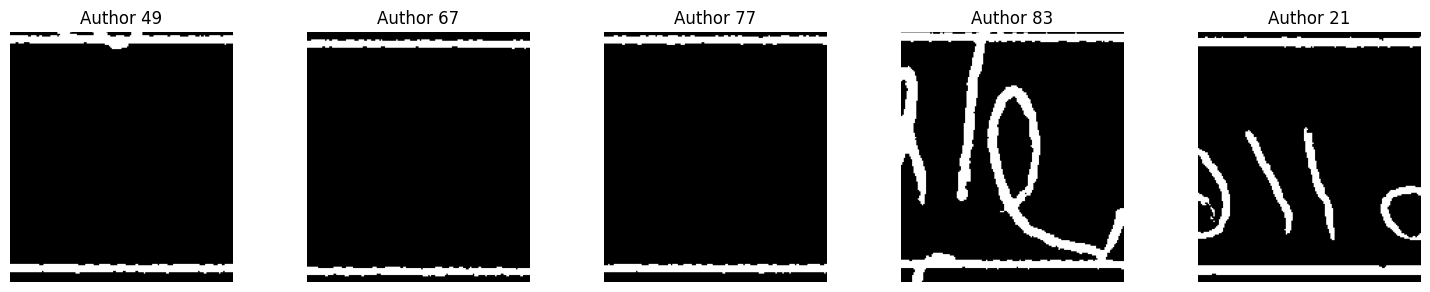

INFO -   - X shape: (54341, 180, 160)
INFO -   - y shape: (54341,)
INFO -   - Unique authors: 107


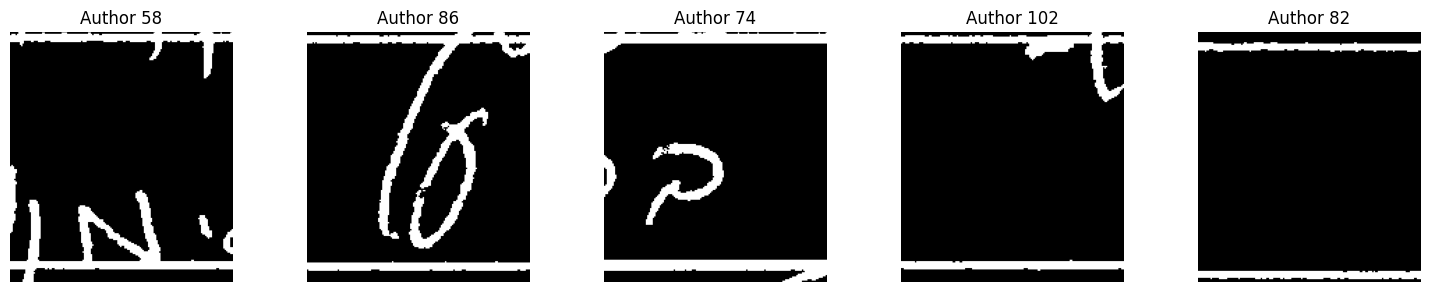

INFO -   - X shape: (13368, 180, 160)
INFO -   - y shape: (13368,)
INFO -   - Unique authors: 107


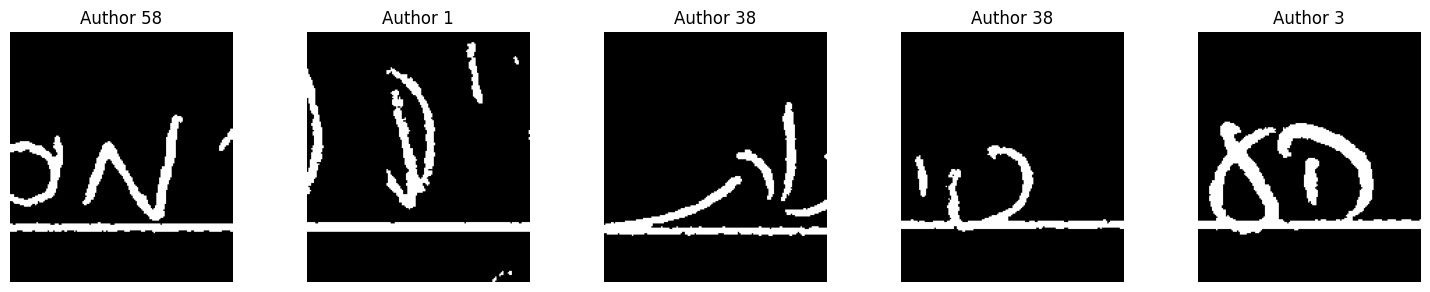

In [28]:
safe_load_authors(loader, range(300, 407))

In [29]:
def get_author_info_safe(loader: SelectiveDataLoader, author_id: int) -> dict | None:
    """Safely get author info with error handling."""
    try:
        info = loader.get_author_info(author_id)
        logger.info(f"Author {author_id} ({info['author_name']}):")
        logger.info(f"  - Train patches: {info['num_patches']['train']}")
        logger.info(f"  - Val patches: {info['num_patches']['validation']}")
        logger.info(f"  - Test patches: {info['num_patches']['test']}")
        return info

    except IndexError as e:
        logger.error(f"❌ Invalid author ID {author_id}: {e}")
        return None

In [30]:
info_0 = get_author_info_safe(loader, 0)

INFO - Author 0 (lines1_Page_01):
INFO -   - Train patches: 3031
INFO -   - Val patches: 496
INFO -   - Test patches: 108


In [31]:
def get_author_info_by_label(loader: SelectiveDataLoader, label: int) -> dict | None:
  try:
    name = loader.get_author_name(label)
    logger.info(f"Label {label} -> {name}")
    return get_author_info_safe(loader, author_id=label)
  except IndexError as e:
    logger.error(f"❌ Invalid label {label}: {e}")
    return None

In [32]:
def get_author_info_by_name(loader: SelectiveDataLoader, name: str) -> dict | None:
  try:
    author_id = loader.get_author_id(author_name=name)
    logger.info(f"{name} -> Label {author_id}")
    return get_author_info_safe(loader, author_id=author_id)
  except IndexError as e:
    logger.error(f"❌ Invalid author name {name}: {e}")
    return None

In [33]:
res = get_author_info_by_label(loader, 0)

INFO - Label 0 -> lines1_Page_01
INFO - Author 0 (lines1_Page_01):
INFO -   - Train patches: 3031
INFO -   - Val patches: 496
INFO -   - Test patches: 108


In [34]:
res = get_author_info_by_name(loader, "lines1_Page_01")

INFO - lines1_Page_01 -> Label 0
INFO - Author 0 (lines1_Page_01):
INFO -   - Train patches: 3031
INFO -   - Val patches: 496
INFO -   - Test patches: 108


In [39]:
del loader
gc.collect()

325